In [31]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [32]:
# print(torch.cuda.is_available())
torch.manual_seed(42)
np.random.seed(42)

In [33]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
device

device(type='cpu')

In [34]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.10
opening_y_max = 0.70


# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    t_open
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape


import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_01_07.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_01_07.pt
Last epoch: 1000
Loss history length: 1000


In [35]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.10
opening_y_max = 0.70

In [36]:
Nx = 100
Ny = 100
L=2
H=1
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

u_pred = u_pred.reshape(Ny, Nx)
v_pred = v_pred.reshape(Ny, Nx)
p_dynamic_pred = p_dynamic_pred.reshape(Ny, Nx)

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * Y
p_pred = p_dynamic_pred + p_hydrostatic


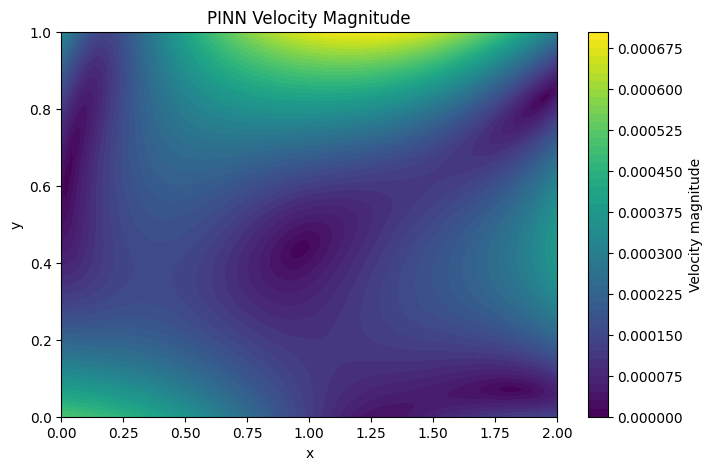

In [37]:
velocity_mag = np.sqrt(
    u_pred**2 + v_pred**2
)

plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    velocity_mag,
    levels=50
)

plt.colorbar(
    label="Velocity magnitude"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Velocity Magnitude")

plt.show()

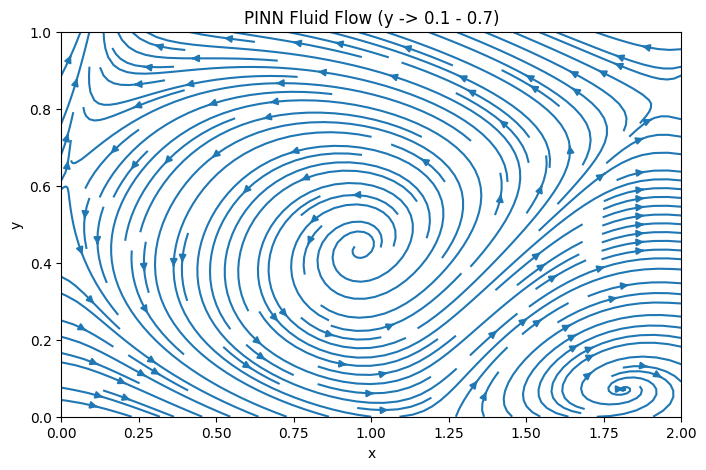

In [38]:
plt.figure(figsize=(8, 5))

plt.streamplot(
    X,
    Y,
    u_pred,
    v_pred,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Fluid Flow (y -> 0.1 - 0.7)")

plt.show()

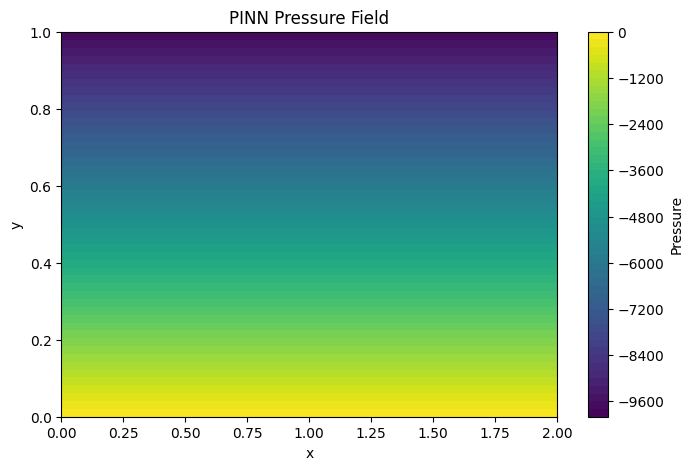

In [39]:
plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    p_pred,
    levels=50
)

plt.colorbar(
    label="Pressure"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Pressure Field")

plt.show()

In [40]:
# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
# t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape

torch.Size([500, 3])

In [41]:
with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open


In [42]:
for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )

y = 0.100 m | u = 0.00010 m/s | v = 0.00006 m/s | p = -981.01208 Pa
y = 0.160 m | u = 0.00024 m/s | v = 0.00001 m/s | p = -1570.79029 Pa
y = 0.220 m | u = 0.00036 m/s | v = -0.00003 m/s | p = -2160.56854 Pa
y = 0.280 m | u = 0.00046 m/s | v = -0.00007 m/s | p = -2750.34682 Pa
y = 0.340 m | u = 0.00054 m/s | v = -0.00011 m/s | p = -3340.12513 Pa
y = 0.401 m | u = 0.00060 m/s | v = -0.00014 m/s | p = -3929.90348 Pa
y = 0.461 m | u = 0.00064 m/s | v = -0.00017 m/s | p = -4519.68186 Pa
y = 0.521 m | u = 0.00065 m/s | v = -0.00019 m/s | p = -5109.46028 Pa
y = 0.581 m | u = 0.00065 m/s | v = -0.00021 m/s | p = -5699.23873 Pa
y = 0.641 m | u = 0.00062 m/s | v = -0.00023 m/s | p = -6289.01723 Pa


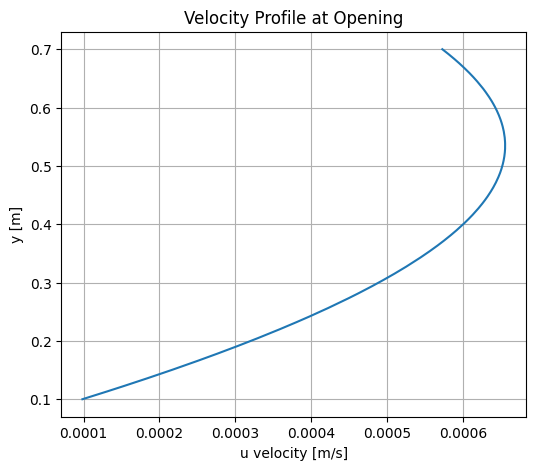

In [43]:
plt.figure(figsize=(6, 5))

plt.plot(
    u_open,
    y_open
)

plt.xlabel("u velocity [m/s]")
plt.ylabel("y [m]")
plt.title("Velocity Profile at Opening")

plt.grid(True)

plt.show()

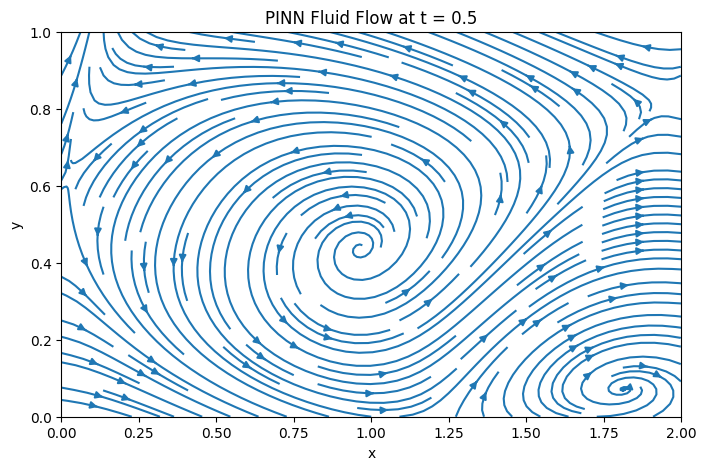

In [44]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 0.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


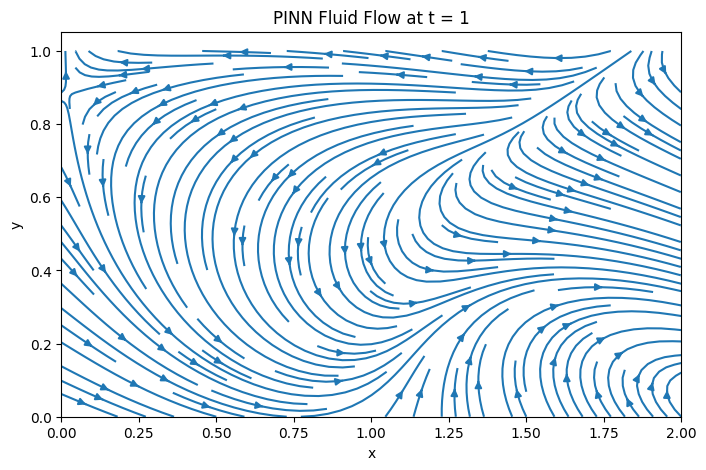

In [45]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


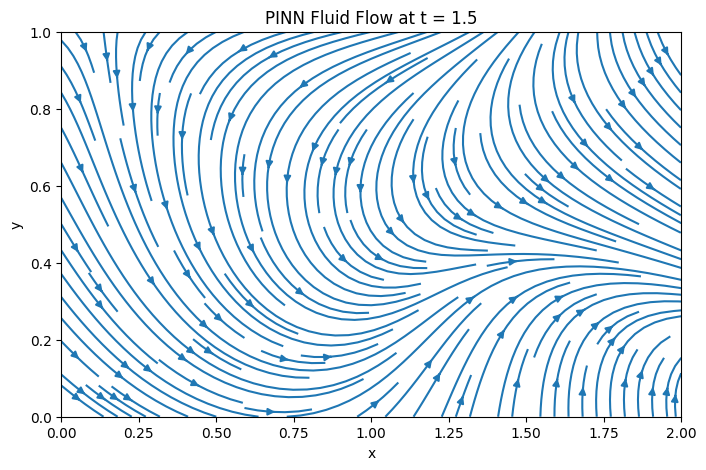

In [46]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


In [ ]:
# Try -> 0.3 - 0.8
# try -> 0.3 - 0.9
# try -> 0.1 - 0.7
# try -> 0.2 - 0.7
# try -> actual naviar stokes equation 

### y-> 0.20 - 0.70

In [29]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.20
opening_y_max = 0.70


import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_02_07.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
# t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
# X_open.shape

with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open

for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_02_07.pt
Last epoch: 1000
Loss history length: 1000
y = 0.200 m | u = 0.00024 m/s | v = -0.00000 m/s | p = -1962.01067 Pa
y = 0.250 m | u = 0.00033 m/s | v = -0.00004 m/s | p = -2453.49248 Pa
y = 0.300 m | u = 0.00041 m/s | v = -0.00007 m/s | p = -2944.97431 Pa
y = 0.350 m | u = 0.00047 m/s | v = -0.00010 m/s | p = -3436.45616 Pa
y = 0.400 m | u = 0.00052 m/s | v = -0.00013 m/s | p = -3927.93803 Pa
y = 0.451 m | u = 0.00056 m/s | v = -0.00015 m/s | p = -4419.41993 Pa
y = 0.501 m | u = 0.00058 m/s | v = -0.00017 m/s | p = -4910.90186 Pa
y = 0.551 m | u = 0.00059 m/s | v = -0.00019 m/s | p = -5402.38381 Pa
y = 0.601 m | u = 0.00058 m/s | v = -0.00020 m/s | p = -5893.86579 Pa
y = 0.651 m | u = 0.00056 m/s | v = -0.00021 m/s | p = -6385.34780 Pa


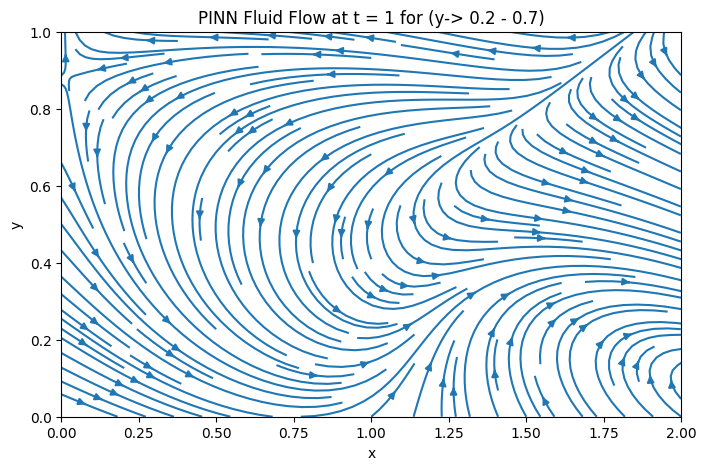

In [30]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot} for (y-> 0.2 - 0.7)")
plt.show()


### y-> 0.30 - 0.90

In [24]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.90


import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_09.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
# t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
# X_open.shape

with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open

for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_09.pt
Last epoch: 1000
Loss history length: 1000
y = 0.300 m | u = 0.00032 m/s | v = -0.00007 m/s | p = -2943.01308 Pa
y = 0.360 m | u = 0.00040 m/s | v = -0.00010 m/s | p = -3532.79121 Pa
y = 0.420 m | u = 0.00046 m/s | v = -0.00013 m/s | p = -4122.56936 Pa
y = 0.480 m | u = 0.00050 m/s | v = -0.00016 m/s | p = -4712.34754 Pa
y = 0.540 m | u = 0.00053 m/s | v = -0.00018 m/s | p = -5302.12576 Pa
y = 0.601 m | u = 0.00053 m/s | v = -0.00020 m/s | p = -5891.90401 Pa
y = 0.661 m | u = 0.00052 m/s | v = -0.00021 m/s | p = -6481.68229 Pa
y = 0.721 m | u = 0.00049 m/s | v = -0.00022 m/s | p = -7071.46061 Pa
y = 0.781 m | u = 0.00044 m/s | v = -0.00023 m/s | p = -7661.23897 Pa
y = 0.841 m | u = 0.00037 m/s | v = -0.00022 m/s | p = -8251.01736 Pa


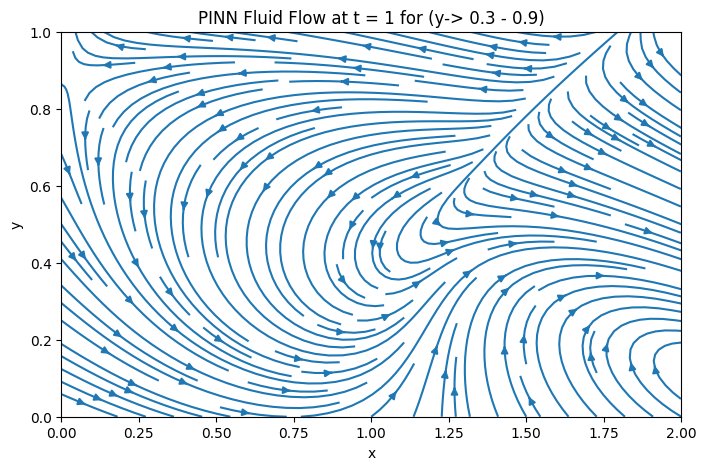

In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot} for (y-> 0.3 - 0.9)")
plt.show()


### y-> 0.30 - 0.80

In [26]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.80


import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_08.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
# t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
# X_open.shape

with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open

for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_08.pt
Last epoch: 1500
Loss history length: 1500
y = 0.300 m | u = 0.00027 m/s | v = -0.00001 m/s | p = -2943.01060 Pa
y = 0.350 m | u = 0.00032 m/s | v = -0.00004 m/s | p = -3434.49240 Pa
y = 0.400 m | u = 0.00036 m/s | v = -0.00005 m/s | p = -3925.97423 Pa
y = 0.450 m | u = 0.00039 m/s | v = -0.00007 m/s | p = -4417.45608 Pa
y = 0.500 m | u = 0.00041 m/s | v = -0.00009 m/s | p = -4908.93796 Pa
y = 0.551 m | u = 0.00042 m/s | v = -0.00010 m/s | p = -5400.41986 Pa
y = 0.601 m | u = 0.00041 m/s | v = -0.00012 m/s | p = -5891.90178 Pa
y = 0.651 m | u = 0.00040 m/s | v = -0.00013 m/s | p = -6383.38373 Pa
y = 0.701 m | u = 0.00037 m/s | v = -0.00014 m/s | p = -6874.86570 Pa
y = 0.751 m | u = 0.00033 m/s | v = -0.00015 m/s | p = -7366.34770 Pa


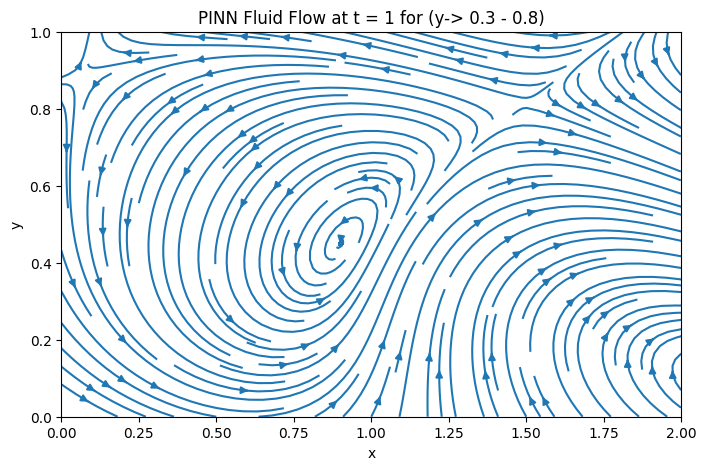

In [28]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot} for (y-> 0.3 - 0.8)")
plt.show()
